In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# 1. Загрузка данных
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Разбиение на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [2]:
# 1
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model =DecisionTreeClassifier(
    criterion = 'gini',
    random_state=42
)

model.fit(X_train, y_train)
print('Train:', accuracy_score(model.predict(X_train), y_train))

print('Test:', accuracy_score(model.predict(X_test), y_test))

Train: 1.0
Test: 0.9122807017543859


In [3]:
# 2
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

best_model = DecisionTreeClassifier(
    criterion = grid_search.best_params_['criterion'],
    max_depth = grid_search.best_params_['max_depth'],
    min_samples_leaf = grid_search.best_params_['min_samples_leaf'],
    min_samples_split = grid_search.best_params_['min_samples_split'],
    random_state=42
)

best_model.fit(X_train, y_train)
print(accuracy_score(best_model.predict(X_test), y_test))


{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
0.9384615384615385
0.9385964912280702


In [12]:
# 3
result = dict()
for name, imp in zip(data.feature_names, best_model.feature_importances_):
    # print(f'{name}: {imp}')
    result[name] = imp

sorted_res = sorted(result.items(), key=lambda x: -x[1])
print(sorted_res[:5])


[(np.str_('worst radius'), np.float64(0.733547574075133)), (np.str_('worst concave points'), np.float64(0.12202752123878562)), (np.str_('texture error'), np.float64(0.04578469013555809)), (np.str_('worst texture'), np.float64(0.0323192601862405)), (np.str_('worst concavity'), np.float64(0.017161164925591495))]


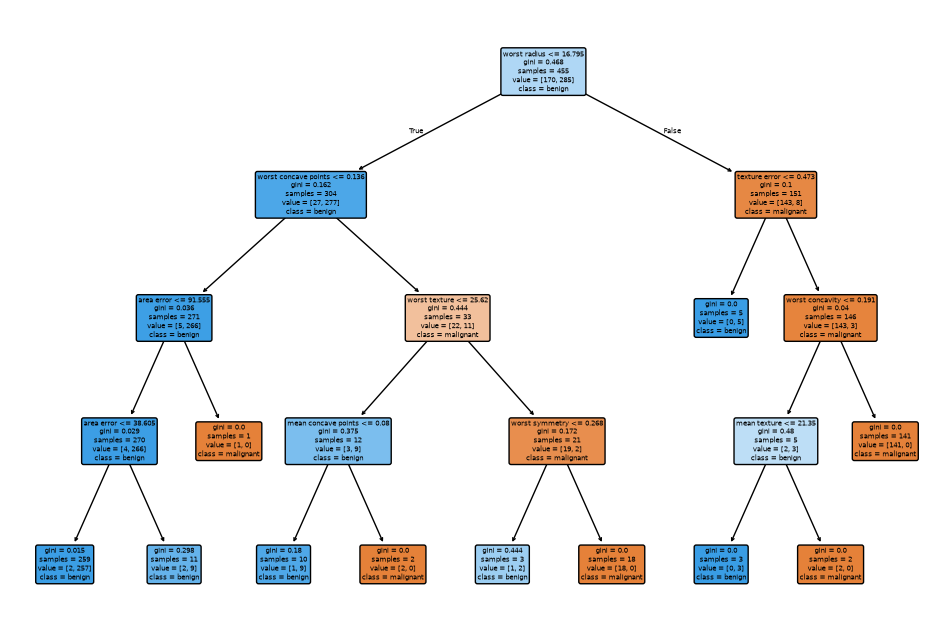

In [18]:
# 4
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))

plot_tree(
    best_model, 
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True
)

plt.show()

In [ ]:
# 1. Сделать предсказание напрямую через grid_search
y_pred = grid_search.predict(X_test)
print('Test Accuracy:', accuracy_score(y_pred, y_test))

# 2. Вытащить готовую обученную модель (например, для отрисовки дерева или важимостей)
best_model = grid_search.best_estimator_

# Отрисовка дерева напрямую из best_estimator_
plot_tree(
    best_model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
)
# По умолчанию в GridSearchCV параметр refit=True. 
# Это значит, что после поиска лучших гиперпараметров 
# он автоматически переобучает модель с этими параметрами на всем X_train.